# 01 — Explore the data & build a baseline recommender

This notebook loads the Coursera reviews and course data, explores it (EDA), and builds a baseline collaborative-filtering model (SVD) evaluated with RMSE/MAE.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy

sns.set_theme()

## 2. Load the data

The Coursera reviews dataset has the columns: reviews, reviewers, date_reviews, rating, course_id.

In [2]:
reviews = pd.read_csv('../data/Coursera_reviews.csv')
courses = pd.read_csv('../data/Coursera_courses.csv')

print('reviews:', reviews.shape)
print('courses:', courses.shape)
reviews.head()

reviews: (1454711, 5)
courses: (623, 4)


,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just t...",By Robert S,"Feb 12, 2020",4,google-cbrs-cpi-training
1,would be a better experience if the video and ...,By Gabriel E R,"Sep 28, 2020",4,google-cbrs-cpi-training
2,Information was perfect! The program itself wa...,By Jacob D,"Apr 08, 2020",4,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do ...,By Dale B,"Feb 24, 2020",4,google-cbrs-cpi-training
4,Excellent course and the training provided was...,By Sean G,"Jun 18, 2020",4,google-cbrs-cpi-training


## 3. Explore the data (EDA)

I plot the ratings distribution and the reviews-per-user distribution to check for skew and sparsity.

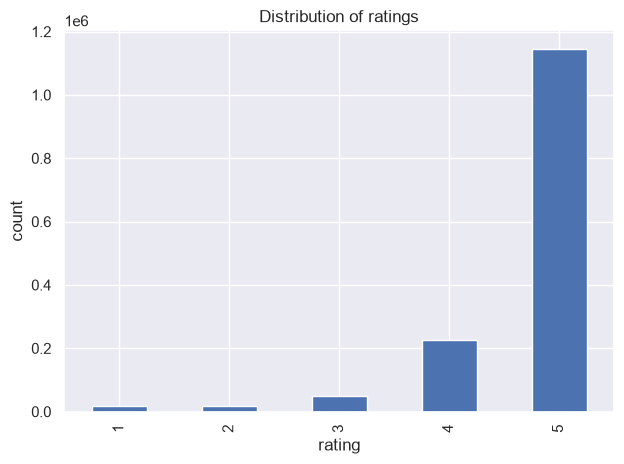

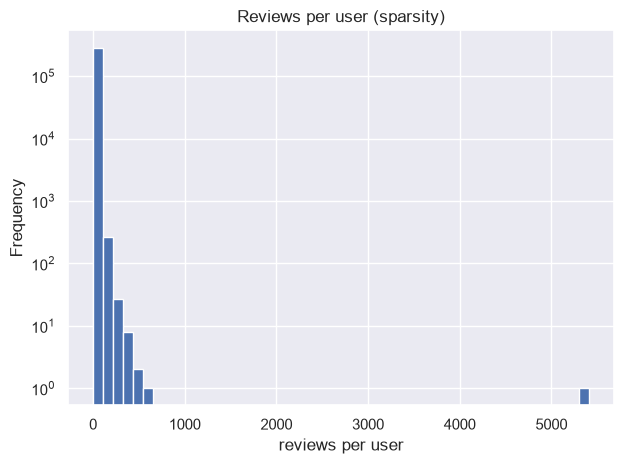

unique users  : 287808
unique courses: 604
avg reviews/user  : 5.05
avg reviews/course: 2408.46


In [3]:
import matplotlib.pyplot as plt
# ratings distribution
reviews['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of ratings'); plt.xlabel('rating'); plt.ylabel('count')
plt.tight_layout(); plt.savefig('ratings_dist.png', dpi=150); plt.show()

# sparsity: reviews per user
reviews['reviewers'].value_counts().plot(kind='hist', bins=50, logy=True)
plt.title('Reviews per user (sparsity)'); plt.xlabel('reviews per user')
plt.tight_layout(); plt.savefig('sparsity.png', dpi=150); plt.show()

# How many reviews per user and per course (sparsity check)
print('unique users  :', reviews['reviewers'].nunique())
print('unique courses:', reviews['course_id'].nunique())
print('avg reviews/user  :', round(reviews.groupby('reviewers').size().mean(), 2))
print('avg reviews/course:', round(reviews.groupby('course_id').size().mean(), 2))

In [4]:
# Top 10 most-reviewed courses
top = reviews['course_id'].value_counts().head(10)
top

course_id
python                            45218
machine-learning                  35895
neural-networks-deep-learning     35750
technical-support-fundamentals    35319
python-data                       33546
learning-how-to-learn             32265
ai-for-everyone                   21630
excel-essentials                  21251
what-is-datascience               21087
the-science-of-well-being         20085
Name: count, dtype: int64

## 4. Baseline recommender — collaborative filtering (SVD)

I use matrix factorisation (SVD) on the user→course ratings and cross-validate it to measure RMSE and MAE.

In [5]:
# Keep just the columns the model needs
df = reviews[['reviewers', 'course_id', 'rating']].dropna()
df.columns = ['user', 'item', 'rating']

# OPTIONAL (for speed): keep users with at least a few reviews so CF has signal
active = df['user'].value_counts()
df = df[df['user'].isin(active[active >= 3].index)]
print('rows used:', len(df))

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user', 'item', 'rating']], reader)

rows used: 1427996


In [6]:
#  Cross-validated evaluation (RMSE / MAE)
results = cross_validate(SVD(random_state=42), data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4376  0.4363  0.4370  0.4387  0.4366  0.4372  0.0009  
MAE (testset)     0.2665  0.2689  0.2679  0.2704  0.2679  0.2683  0.0013  
Fit time          4.90    5.68    4.78    4.82    4.73    4.98    0.35    
Test time         0.96    0.74    0.84    0.68    0.87    0.82    0.10    


## 5. Train on all data and make recommendations for one user

In [7]:
trainset = data.build_full_trainset()
model = SVD(random_state=42)
model.fit(trainset)

def recommend(user, n=10):
    seen = set(df.loc[df['user'] == user, 'item'])
    items = [i for i in df['item'].unique() if i not in seen]
    preds = [(i, model.predict(user, i).est) for i in items]
    preds.sort(key=lambda x: x[1], reverse=True)
    return preds[:n]

sample_user = df['user'].iloc[0]
print('Recommendations for', sample_user)
recommend(sample_user, 10)

Recommendations for By Robert S


[('visual-elements-user-interface-design', 5),
 ('computational-thinking-problem-solving', 5),
 ('user-experience-design', 5),
 ('introduction-to-ai', 5),
 ('fashion-design', 5),
 ('decision-making', 5),
 ('information-security-data', 5),
 ('creative-problem-solving', np.float64(4.995916768144135)),
 ('physiology', np.float64(4.991497358371554)),
 ('uva-darden-digital-product-management', np.float64(4.976544304659619))]

## 6. Limitations of this baseline

RMSE measures rating accuracy, not ranking quality. The next notebook adds precision@k and recall@k, a content-based model, and a hybrid, then compares all three.